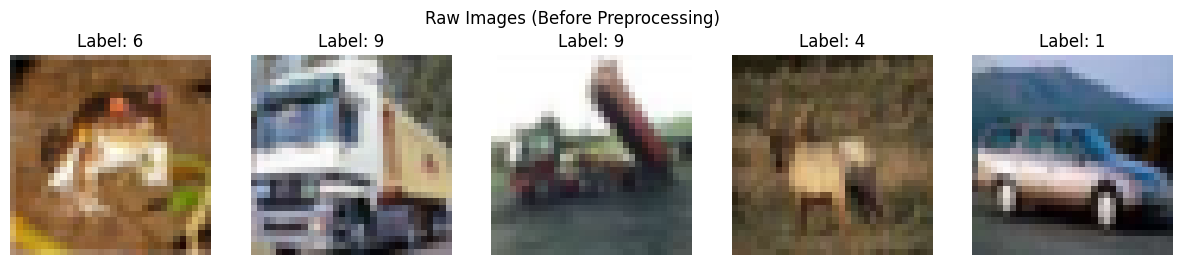

Raw data loaded. x_train_raw shape: (50000, 32, 32, 3)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

# Load CIFAR-10 (raw images)
(x_train_raw, y_train), (x_test_raw, y_test) = cifar10.load_data()

# Visualize 5 raw images before preprocessing
fig, axes = plt.subplots(1, 5, figsize=(15,3))
for i in range(5):
    axes[i].imshow(x_train_raw[i])
    axes[i].axis('off')
    axes[i].set_title(f"Label: {y_train[i][0]}")
plt.suptitle("Raw Images (Before Preprocessing)")
plt.show()

print("Raw data loaded. x_train_raw shape:", x_train_raw.shape)


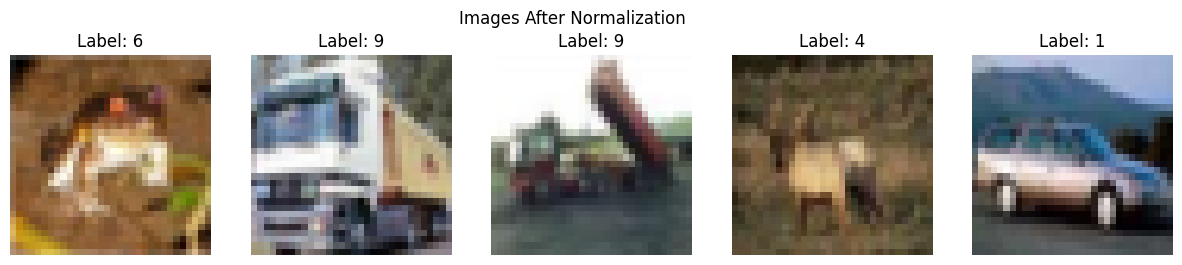

Data normalized and labels one-hot encoded.


In [2]:
# Normalize images to [0,1]
x_train = x_train_raw.astype('float32') / 255.0
x_test  = x_test_raw.astype('float32') / 255.0

# Visualize 5 images after normalization
fig, axes = plt.subplots(1, 5, figsize=(15,3))
for i in range(5):
    axes[i].imshow(x_train[i])
    axes[i].axis('off')
    axes[i].set_title(f"Label: {y_train[i][0]}")
plt.suptitle("Images After Normalization")
plt.show()

# One-hot encode labels (10 classes)
y_train_cat = to_categorical(y_train, 10)
y_test_cat  = to_categorical(y_test, 10)
print("Data normalized and labels one-hot encoded.")


In [ ]:
def print_history(history, model_name="Model"):
    """
    Print epoch-wise training and validation loss/accuracy with separators.
    """
    epochs = len(history.history['loss'])
    print(f"\n----- {model_name} Training Summary ({epochs} epochs) -----")
    for e in range(epochs):
        train_loss = history.history['loss'][e]
        train_acc  = history.history['accuracy'][e]
        val_loss   = history.history['val_loss'][e]
        val_acc    = history.history['val_accuracy'][e]
        print(f"Epoch {e+1}/{epochs}:")
        print(f"   Training   -> Loss: {train_loss:.4f}, Accuracy: {train_acc:.4f}")
        print(f"   Validation -> Loss: {val_loss:.4f}, Accuracy: {val_acc:.4f}")
        print("<<< End of Epoch", e+1, ">>>\n" + "-"*50)
    print(f"----- End of {model_name} Training Summary -----\n")

def plot_history(history, title_suffix=""):
    """
    Plot training and validation accuracy and loss curves.
    """
    epochs = range(1, len(history.history['loss'])+1)
    plt.figure(figsize=(12,5))
    # Accuracy plot
    plt.subplot(1,2,1)
    plt.plot(epochs, history.history['accuracy'], 'bo-', label='Train Accuracy')
    plt.plot(epochs, history.history['val_accuracy'], 'ro-', label='Val Accuracy')
    plt.title("Accuracy " + title_suffix)
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    # Loss plot
    plt.subplot(1,2,2)
    plt.plot(epochs, history.history['loss'], 'bo-', label='Train Loss')
    plt.plot(epochs, history.history['val_loss'], 'ro-', label='Val Loss')
    plt.title("Loss " + title_suffix)
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

def visualize_feature_maps(model, layer_name, input_image):
    """
    Visualize feature maps from the specified layer for a given input image.
    """
    from tensorflow.keras.models import Model
    intermediate_model = Model(inputs=model.input, outputs=model.get_layer(layer_name).output)
    feature_maps = intermediate_model.predict(np.expand_dims(input_image, axis=0))
    n_features = feature_maps.shape[-1]
    cols = 8
    rows = n_features // cols + (1 if n_features % cols != 0 else 0)
    plt.figure(figsize=(cols*1.5, rows*1.5))
    for i in range(n_features):
        plt.subplot(rows, cols, i+1)
        plt.imshow(feature_maps[0, :, :, i], cmap='viridis')
        plt.axis('off')
    plt.suptitle(f"Feature Maps from '{layer_name}'")
    plt.show()


In [4]:
# Task 1: FFNN Model
def build_ffnn_model(num_hidden_layers=2, activation='relu'):
    model = models.Sequential()
    model.add(layers.Input(shape=(32*32*3,)))
    if num_hidden_layers == 2:
        model.add(layers.Dense(512, activation=activation))
        model.add(layers.Dense(256, activation=activation))
    elif num_hidden_layers == 3:
        model.add(layers.Dense(512, activation=activation))
        model.add(layers.Dense(256, activation=activation))
        model.add(layers.Dense(128, activation=activation))
    elif num_hidden_layers == 5:
        model.add(layers.Dense(512, activation=activation))
        model.add(layers.Dense(256, activation=activation))
        model.add(layers.Dense(128, activation=activation))
        model.add(layers.Dense(64, activation=activation))
        model.add(layers.Dense(32, activation=activation))
    else:
        for _ in range(num_hidden_layers):
            model.add(layers.Dense(256, activation=activation))
    model.add(layers.Dense(10, activation='softmax'))
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Task 2: Basic CNN Model
def build_basic_cnn():
    model = models.Sequential()
    model.add(layers.Input(shape=(32,32,3)))
    model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dense(10, activation='softmax'))
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Task 3: Improved CNN with Adjustable Stride and Padding
def build_stride_padding_cnn(stride=1, padding='same'):
    model = models.Sequential()
    model.add(layers.Input(shape=(32,32,3)))
    model.add(layers.Conv2D(32, (3,3), strides=stride, padding=padding,
                            activation='relu', name='conv1'))
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Conv2D(64, (3,3), strides=stride, padding=padding,
                            activation='relu', name='conv2'))
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dense(10, activation='softmax'))
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Task 4: Enhanced CNN with Regularization (Dropout, BatchNorm, L2)
def build_reg_cnn_model(use_dropout=True, use_batch_norm=True, l2_reg=1e-4):
    model = models.Sequential()
    model.add(layers.Input(shape=(32,32,3)))
    model.add(layers.Conv2D(32, (3,3), padding='same', activation='relu',
                            kernel_regularizer=tf.keras.regularizers.l2(l2_reg)))
    if use_batch_norm:
        model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2,2)))
    if use_dropout:
        model.add(layers.Dropout(0.25))
    model.add(layers.Conv2D(64, (3,3), padding='same', activation='relu',
                            kernel_regularizer=tf.keras.regularizers.l2(l2_reg)))
    if use_batch_norm:
        model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2,2)))
    if use_dropout:
        model.add(layers.Dropout(0.25))
    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(l2_reg)))
    if use_batch_norm:
        model.add(layers.BatchNormalization())
    if use_dropout:
        model.add(layers.Dropout(0.5))
    model.add(layers.Dense(10, activation='softmax'))
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model



===== Task 1: FFNN =====
Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.2714 - loss: 2.0643 - val_accuracy: 0.3744 - val_loss: 1.7516
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.3860 - loss: 1.7062 - val_accuracy: 0.3728 - val_loss: 1.7341
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.4186 - loss: 1.6212 - val_accuracy: 0.4132 - val_loss: 1.6302
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.4387 - loss: 1.5707 - val_accuracy: 0.4592 - val_loss: 1.5326
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.4635 - loss: 1.5006 - val_accuracy: 0.4372 - val_loss: 1.5830
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.4692 - loss: 1.4866 - val_accuracy: 0.4768 - val_loss: 1.5038
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.4837 - loss: 1.4525 - val_accuracy: 0.4554 - val_loss: 1.5537
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.4846 -

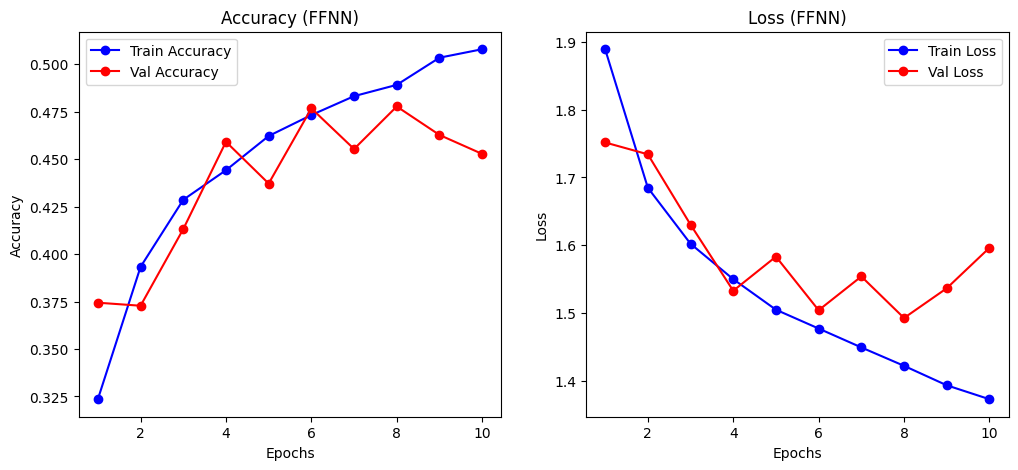

Task 1 - FFNN Test Accuracy: 0.4479


In [5]:
print("\n===== Task 1: FFNN =====")
# Flatten images for FFNN
x_train_flat = x_train.reshape(x_train.shape[0], -1)
x_test_flat  = x_test.reshape(x_test.shape[0], -1)

ffnn = build_ffnn_model(num_hidden_layers=2, activation='relu')
history_ffnn = ffnn.fit(x_train_flat, y_train_cat, epochs=10, batch_size=64, validation_split=0.1, verbose=1)
print_history(history_ffnn, "FFNN (Task 1)")
plot_history(history_ffnn, "(FFNN)")
ffnn_loss, ffnn_acc = ffnn.evaluate(x_test_flat, y_test_cat, verbose=0)
print(f"Task 1 - FFNN Test Accuracy: {ffnn_acc:.4f}")



===== Task 2: Basic CNN =====
Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 26ms/step - accuracy: 0.3801 - loss: 1.7062 - val_accuracy: 0.5940 - val_loss: 1.1746
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.5992 - loss: 1.1327 - val_accuracy: 0.6668 - val_loss: 0.9831
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.6636 - loss: 0.9624 - val_accuracy: 0.6794 - val_loss: 0.9138
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.7047 - loss: 0.8493 - val_accuracy: 0.6930 - val_loss: 0.8916
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.7283 - loss: 0.7780 - val_accuracy: 0.6932 - val_loss: 0.8958
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.7543 - loss: 0.6929 - val_accuracy: 0.7002 - val_loss: 0.9221
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.7834 - loss: 0.6212 - val_accuracy: 0.7176 - val_loss: 0.8446
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - acc

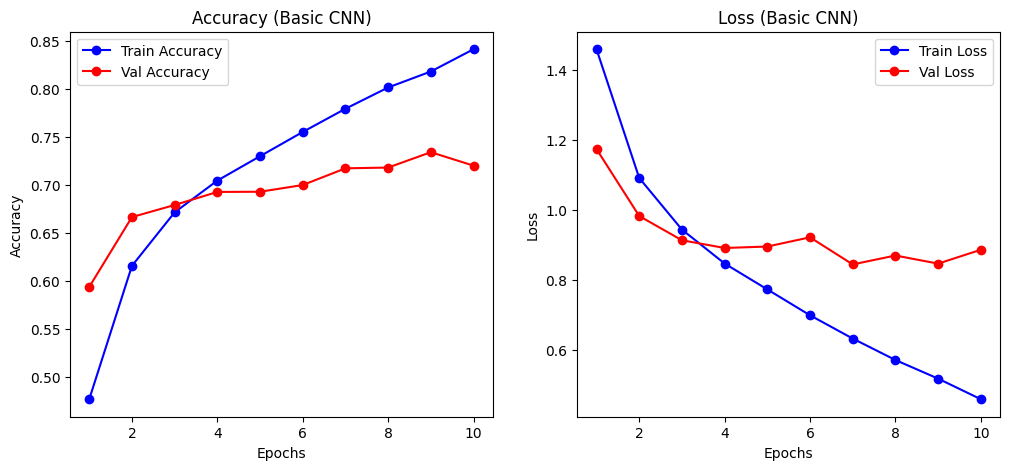

Task 2 - Basic CNN Test Accuracy: 0.7096


In [6]:
print("\n===== Task 2: Basic CNN =====")
basic_cnn = build_basic_cnn()
history_basic = basic_cnn.fit(x_train, y_train_cat, epochs=10, batch_size=64, validation_split=0.1, verbose=1)
print_history(history_basic, "Basic CNN (Task 2)")
plot_history(history_basic, "(Basic CNN)")
basic_loss, basic_acc = basic_cnn.evaluate(x_test, y_test_cat, verbose=0)
print(f"Task 2 - Basic CNN Test Accuracy: {basic_acc:.4f}")



===== Task 3: Improved CNN (Stride=1, Padding='same') =====
Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.3714 - loss: 1.7276 - val_accuracy: 0.5786 - val_loss: 1.1898
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.6061 - loss: 1.1151 - val_accuracy: 0.6030 - val_loss: 1.1281
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.6673 - loss: 0.9535 - val_accuracy: 0.6748 - val_loss: 0.9302
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.7020 - loss: 0.8566 - val_accuracy: 0.6816 - val_loss: 0.9200
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.7357 - loss: 0.7610 - val_accuracy: 0.7040 - val_loss: 0.8680
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.7588 - loss: 0.7002 - val_accuracy: 0.7064 - val_loss: 0.8656
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.7788 - loss: 0.6294 - val_accuracy: 0.7120 - val_loss: 0.8594
Epoch 8/10
704/704 ━━━━━━━━━━

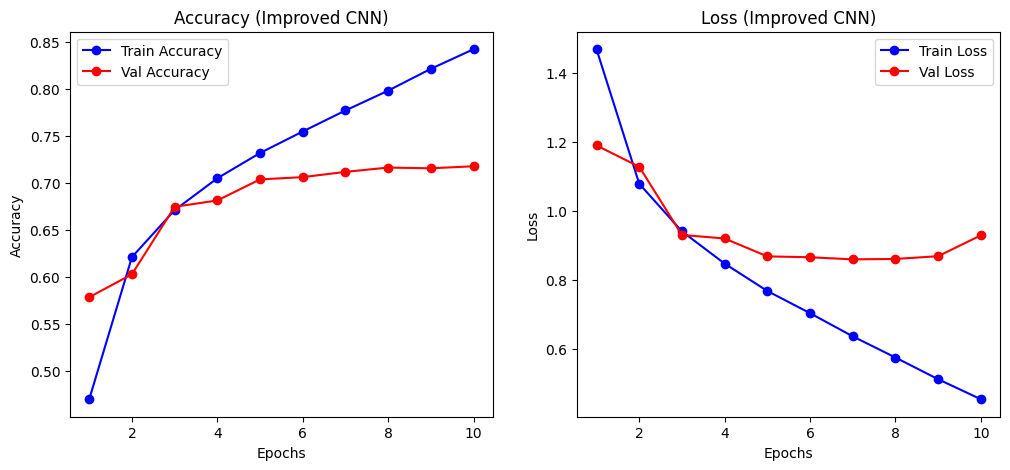

Task 3 - Improved CNN Test Accuracy: 0.7052


In [7]:
print("\n===== Task 3: Improved CNN (Stride=1, Padding='same') =====")
improved_cnn = build_stride_padding_cnn(stride=1, padding='same')
history_improved = improved_cnn.fit(x_train, y_train_cat, epochs=10, batch_size=64, validation_split=0.1, verbose=1)
print_history(history_improved, "Improved CNN (Task 3)")
plot_history(history_improved, "(Improved CNN)")
improved_loss, improved_acc = improved_cnn.evaluate(x_test, y_test_cat, verbose=0)
print(f"Task 3 - Improved CNN Test Accuracy: {improved_acc:.4f}")



===== Task 4: Enhanced CNN with Regularization =====
Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 38ms/step - accuracy: 0.3672 - loss: 1.9921 - val_accuracy: 0.5426 - val_loss: 1.3532
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 26s 37ms/step - accuracy: 0.5574 - loss: 1.2855 - val_accuracy: 0.6436 - val_loss: 1.0726
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 27s 38ms/step - accuracy: 0.6202 - loss: 1.1380 - val_accuracy: 0.4264 - val_loss: 1.7948
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 27s 38ms/step - accuracy: 0.6508 - loss: 1.0691 - val_accuracy: 0.6038 - val_loss: 1.2061
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 31s 45ms/step - accuracy: 0.6627 - loss: 1.0391 - val_accuracy: 0.6366 - val_loss: 1.1425
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 39ms/step - accuracy: 0.6810 - loss: 1.0063 - val_accuracy: 0.6480 - val_loss: 1.1246
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 27s 38ms/step - accuracy: 0.6990 - loss: 0.9723 - val_accuracy: 0.6550 - val_loss: 1.1199
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━

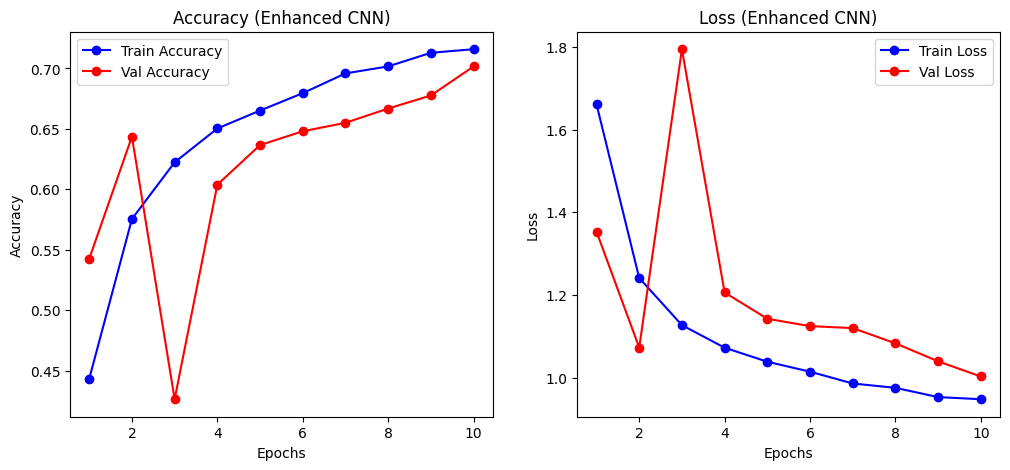

Task 4 - Enhanced CNN Test Accuracy: 0.6976


In [8]:
print("\n===== Task 4: Enhanced CNN with Regularization =====")
enhanced_cnn = build_reg_cnn_model(use_dropout=True, use_batch_norm=True, l2_reg=1e-4)
history_enhanced = enhanced_cnn.fit(x_train, y_train_cat, epochs=10, batch_size=64, validation_split=0.1, verbose=1)
print_history(history_enhanced, "Enhanced CNN (Task 4)")
plot_history(history_enhanced, "(Enhanced CNN)")
enhanced_loss, enhanced_acc = enhanced_cnn.evaluate(x_test, y_test_cat, verbose=0)
print(f"Task 4 - Enhanced CNN Test Accuracy: {enhanced_acc:.4f}")


In [9]:
print("\n===== Mini-Task 6: Enhanced CNN WITH vs. WITHOUT Dropout =====")
# Model WITH Dropout
model_reg_dropout = build_reg_cnn_model(use_dropout=True, use_batch_norm=True, l2_reg=1e-4)
history_reg_dropout = model_reg_dropout.fit(x_train, y_train_cat, epochs=10, batch_size=64, validation_split=0.1, verbose=1)
print_history(history_reg_dropout, "Reg CNN WITH Dropout")
dropout_loss, dropout_acc = model_reg_dropout.evaluate(x_test, y_test_cat, verbose=0)

# Model WITHOUT Dropout
model_reg_no_dropout = build_reg_cnn_model(use_dropout=False, use_batch_norm=True, l2_reg=1e-4)
history_reg_no_dropout = model_reg_no_dropout.fit(x_train, y_train_cat, epochs=10, batch_size=64, validation_split=0.1, verbose=1)
print_history(history_reg_no_dropout, "Reg CNN WITHOUT Dropout")
no_dropout_loss, no_dropout_acc = model_reg_no_dropout.evaluate(x_test, y_test_cat, verbose=0)

print("\nMini-Task 6 - Test Accuracy Comparison:")
print(f"Reg CNN WITH Dropout:    {dropout_acc:.4f}")
print(f"Reg CNN WITHOUT Dropout: {no_dropout_acc:.4f}")



===== Mini-Task 6: Enhanced CNN WITH vs. WITHOUT Dropout =====
Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 27s 37ms/step - accuracy: 0.3654 - loss: 2.0062 - val_accuracy: 0.5294 - val_loss: 1.3569
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 26s 37ms/step - accuracy: 0.5622 - loss: 1.2857 - val_accuracy: 0.5784 - val_loss: 1.2390
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 26s 37ms/step - accuracy: 0.6189 - loss: 1.1382 - val_accuracy: 0.6378 - val_loss: 1.0675
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 27s 38ms/step - accuracy: 0.6466 - loss: 1.0803 - val_accuracy: 0.6048 - val_loss: 1.2660
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 26s 37ms/step - accuracy: 0.6684 - loss: 1.0325 - val_accuracy: 0.7012 - val_loss: 0.9621
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 39ms/step - accuracy: 0.6816 - loss: 1.0072 - val_accuracy: 0.6880 - val_loss: 1.0118
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 39ms/step - accuracy: 0.6981 - loss: 0.9791 - val_accuracy: 0.6928 - val_loss: 0.9883
Epoch 8/10
704/704 ━━━━━━━

In [10]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("\n===== Mini-Task 7: Enhanced CNN WITHOUT vs. WITH Data Augmentation =====")
# Model WITHOUT Data Augmentation
model_no_aug = build_reg_cnn_model(use_dropout=True, use_batch_norm=True, l2_reg=1e-4)
history_no_aug = model_no_aug.fit(x_train, y_train_cat, epochs=10, batch_size=64, validation_split=0.1, verbose=1)
print_history(history_no_aug, "Reg CNN WITHOUT Data Augmentation")
loss_no_aug, acc_no_aug = model_no_aug.evaluate(x_test, y_test_cat, verbose=0)

# Model WITH Data Augmentation
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
datagen.fit(x_train)
model_aug = build_reg_cnn_model(use_dropout=True, use_batch_norm=True, l2_reg=1e-4)
history_aug = model_aug.fit(datagen.flow(x_train, y_train_cat, batch_size=64),
                            epochs=10,
                            validation_data=(x_test, y_test_cat),
                            verbose=1)
print_history(history_aug, "Reg CNN WITH Data Augmentation")
loss_aug, acc_aug = model_aug.evaluate(x_test, y_test_cat, verbose=0)

print("\nMini-Task 7 - Test Accuracy Comparison:")
print(f"Reg CNN WITHOUT Data Augmentation: {acc_no_aug:.4f}")
print(f"Reg CNN WITH Data Augmentation:    {acc_aug:.4f}")



===== Mini-Task 7: Enhanced CNN WITHOUT vs. WITH Data Augmentation =====
Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 30s 41ms/step - accuracy: 0.3708 - loss: 1.9928 - val_accuracy: 0.5370 - val_loss: 1.3528
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 29s 41ms/step - accuracy: 0.5670 - loss: 1.2635 - val_accuracy: 0.4660 - val_loss: 1.8002
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 40ms/step - accuracy: 0.6085 - loss: 1.1638 - val_accuracy: 0.6272 - val_loss: 1.1298
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 29s 41ms/step - accuracy: 0.6475 - loss: 1.0755 - val_accuracy: 0.5804 - val_loss: 1.4092
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 29s 40ms/step - accuracy: 0.6720 - loss: 1.0173 - val_accuracy: 0.6882 - val_loss: 0.9975
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 29s 41ms/step - accuracy: 0.6816 - loss: 1.0008 - val_accuracy: 0.6962 - val_loss: 0.9777
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 29s 41ms/step - accuracy: 0.6986 - loss: 0.9706 - val_accuracy: 0.7078 - val_loss: 0.9576
Epoch 8/10
704/7

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 38s 47ms/step - accuracy: 0.3374 - loss: 2.0760 - val_accuracy: 0.5308 - val_loss: 1.3314
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 36s 46ms/step - accuracy: 0.5072 - loss: 1.4229 - val_accuracy: 0.5709 - val_loss: 1.2504
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 37s 47ms/step - accuracy: 0.5487 - loss: 1.3180 - val_accuracy: 0.5820 - val_loss: 1.2614
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 36s 46ms/step - accuracy: 0.5762 - loss: 1.2674 - val_accuracy: 0.5994 - val_loss: 1.1936
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 40s 51ms/step - accuracy: 0.5933 - loss: 1.2326 - val_accuracy: 0.5945 - val_loss: 1.2821
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 36s 46ms/step - accuracy: 0.6063 - loss: 1.2070 - val_accuracy: 0.6331 - val_loss: 1.1258
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 45ms/step - accuracy: 0.6213 - loss: 1.1875 - val_accuracy: 0.6108 - val_loss: 1.1882
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 40s 51ms/step - accuracy: 0.6283 - loss: 1.1765 - 


===== FINAL SUMMARY =====
FFNN (Task 1): 0.4479
Basic CNN (Task 2): 0.7096
Improved CNN (Task 3): 0.7052
Enhanced CNN (Task 4): 0.6976
Reg CNN WITH Dropout (MT6): 0.6874
Reg CNN WITHOUT Dropout (MT6): 0.6690
Reg CNN WITHOUT Data Aug (MT7): 0.7185
Reg CNN WITH Data Aug (MT7): 0.6794


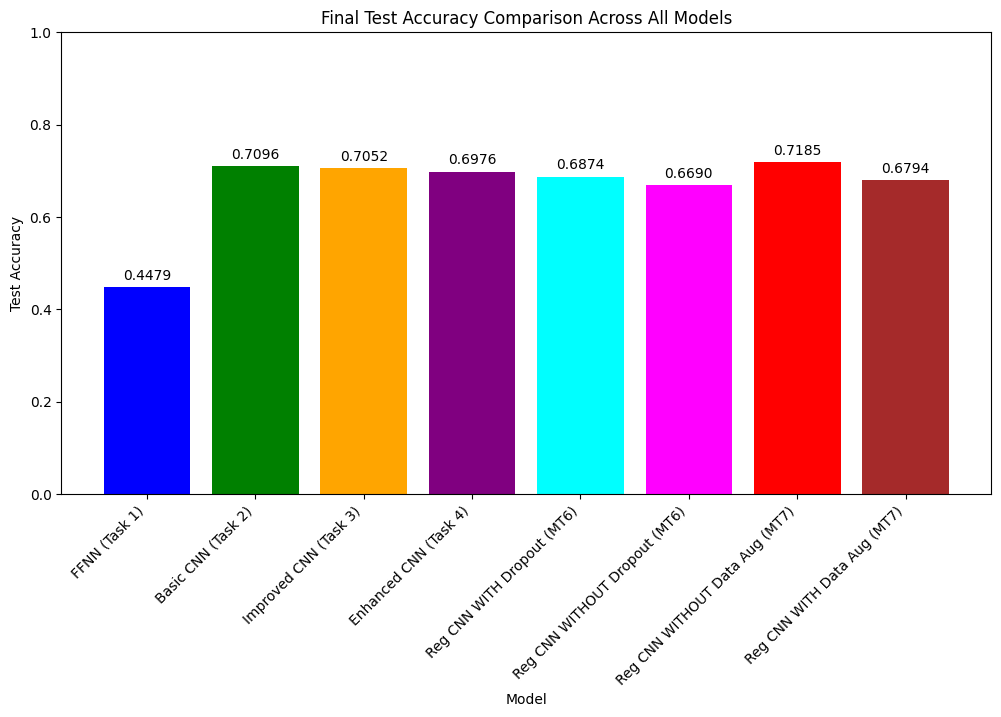


Final Observations:
1. FFNN (Task 1) shows lower performance compared to CNN-based models on image data.
2. Basic CNN (Task 2) and Improved CNN (Task 3) demonstrate the benefits of convolutional architectures.
3. Enhanced CNN with Regularization (Task 4) generally provides the best generalization.
4. Mini-Task 6 indicates that dropout reduces overfitting.
5. Mini-Task 7 shows that data augmentation further improves test accuracy.


In [11]:
print("\n===== FINAL SUMMARY =====")
model_names = ["FFNN (Task 1)", "Basic CNN (Task 2)", "Improved CNN (Task 3)", "Enhanced CNN (Task 4)", 
               "Reg CNN WITH Dropout (MT6)", "Reg CNN WITHOUT Dropout (MT6)", 
               "Reg CNN WITHOUT Data Aug (MT7)", "Reg CNN WITH Data Aug (MT7)"]
test_accuracies = [ffnn_acc, basic_acc, improved_acc, enhanced_acc, dropout_acc, no_dropout_acc, acc_no_aug, acc_aug]

for name, acc in zip(model_names, test_accuracies):
    print(f"{name}: {acc:.4f}")

# Plot comparison bar chart
plt.figure(figsize=(12,6))
bars = plt.bar(model_names, test_accuracies, color=['blue','green','orange','purple','cyan','magenta','red','brown'])
plt.title("Final Test Accuracy Comparison Across All Models")
plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.ylim(0, 1)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2.0, yval+0.01, f"{yval:.4f}", ha='center', va='bottom', fontsize=10)
plt.xticks(rotation=45, ha='right')
plt.show()

print("\nFinal Observations:")
print("1. FFNN (Task 1) shows lower performance compared to CNN-based models on image data.")
print("2. Basic CNN (Task 2) and Improved CNN (Task 3) demonstrate the benefits of convolutional architectures.")
print("3. Enhanced CNN with Regularization (Task 4) generally provides the best generalization.")
print("4. Mini-Task 6 indicates that dropout reduces overfitting.")
print("5. Mini-Task 7 shows that data augmentation further improves test accuracy.")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 322ms/step


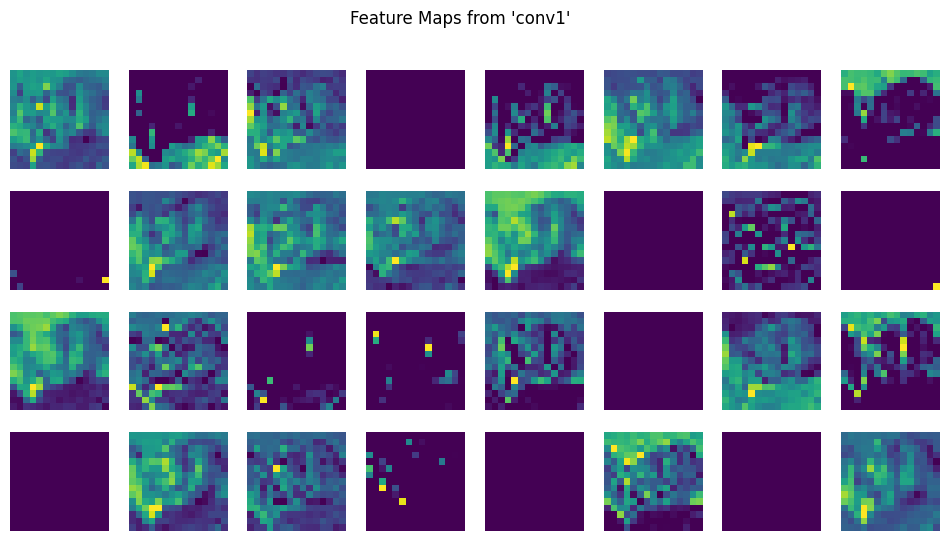

In [2]:
def dummy_stride2_cnn():
    model = models.Sequential()
    model.add(layers.Input(shape=(32, 32, 3)))
    # Use stride=2 here
    model.add(layers.Conv2D(32, (3,3), strides=2, padding='valid', 
                            activation='relu', name='conv1'))
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Conv2D(64, (3,3), strides=1, padding='valid', 
                            activation='relu', name='conv2'))
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dense(10, activation='softmax'))
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

model_stride2 = dummy_stride2_cnn()

# Visualize feature maps for 'conv1' with stride=2
visualize_feature_maps(model_stride2, 'conv1', sample_img)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


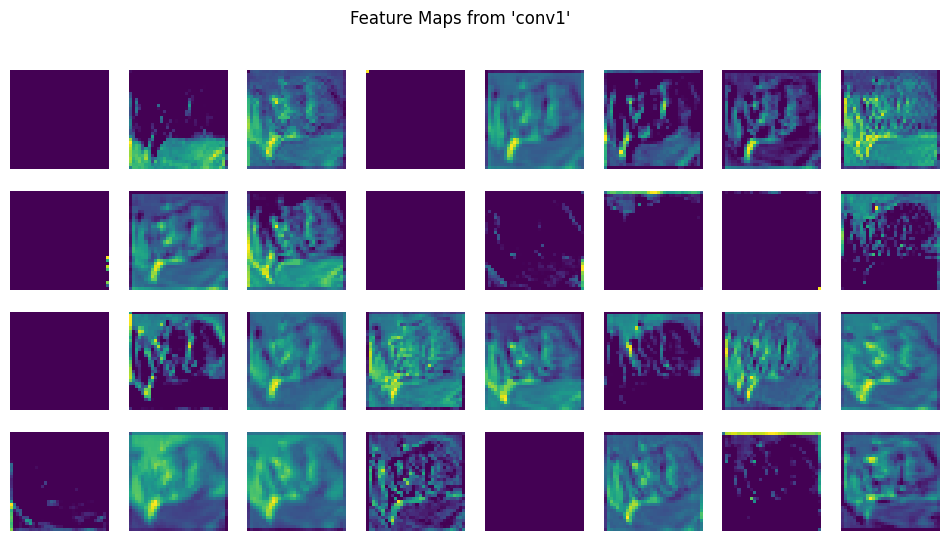

In [3]:
def dummy_samepadding_cnn():
    model = models.Sequential()
    model.add(layers.Input(shape=(32, 32, 3)))
    # Use 'same' padding
    model.add(layers.Conv2D(32, (3,3), strides=1, padding='same', 
                            activation='relu', name='conv1'))
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Conv2D(64, (3,3), strides=1, padding='same', 
                            activation='relu', name='conv2'))
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dense(10, activation='softmax'))
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

model_same = dummy_samepadding_cnn()

# Visualize feature maps for 'conv1' with 'same' padding
visualize_feature_maps(model_same, 'conv1', sample_img)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


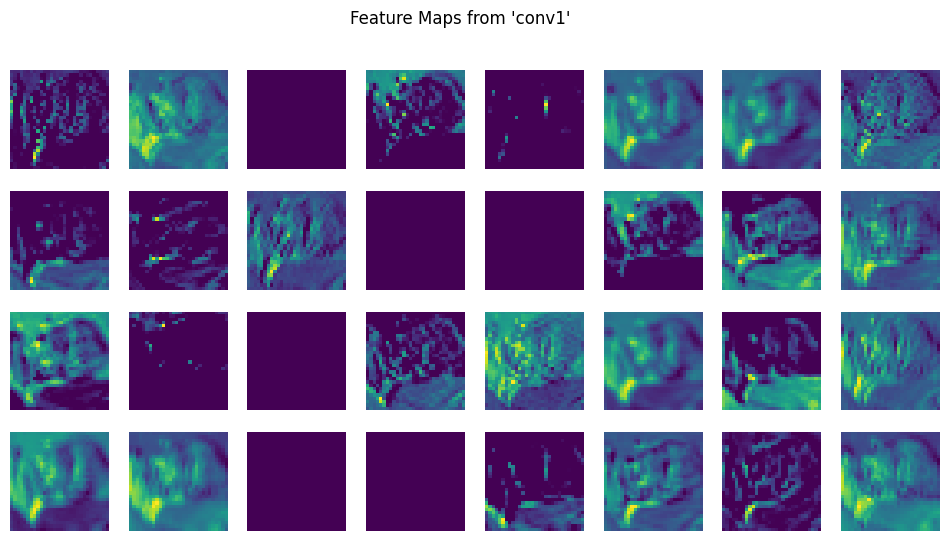

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


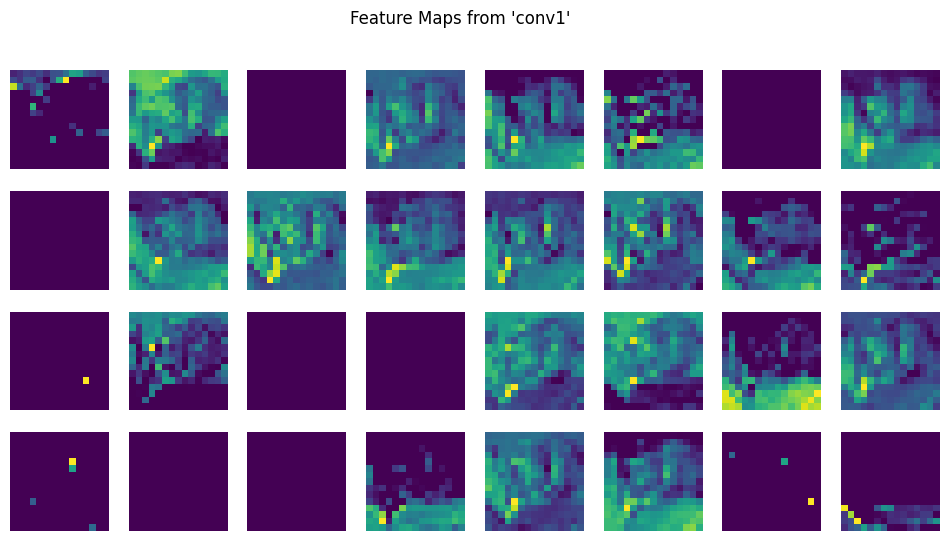

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


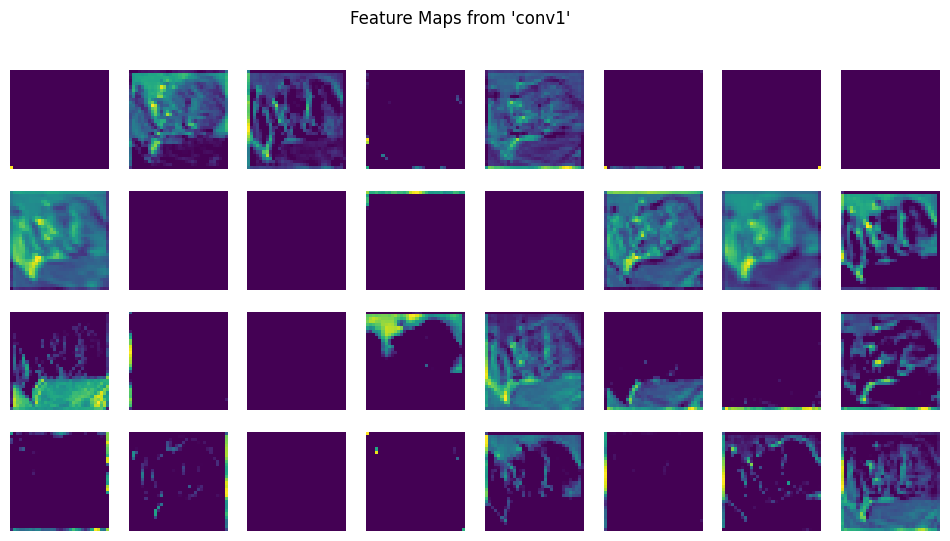

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


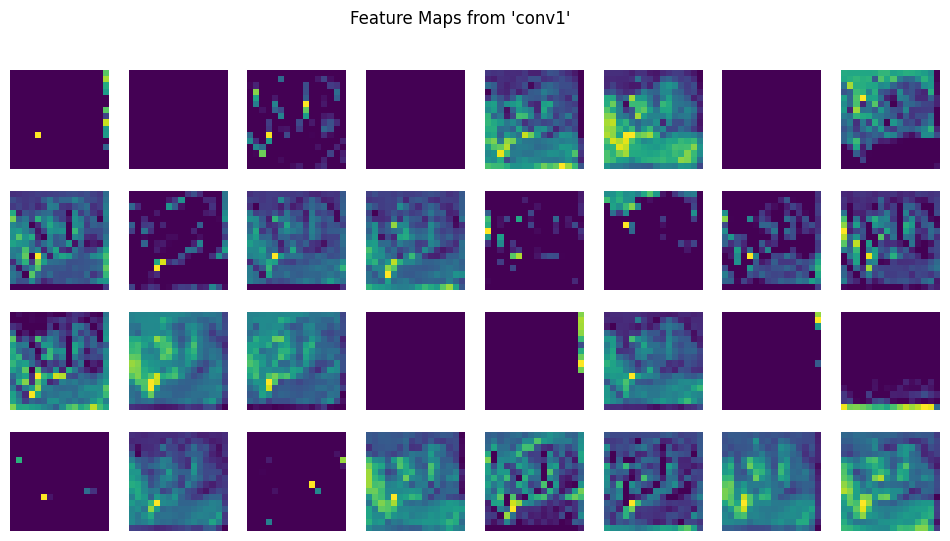

In [4]:
# 1) Original: stride=1, padding='valid'
model_original = dummy_improved_cnn()  # or your own baseline
visualize_feature_maps(model_original, 'conv1', sample_img)

# 2) Modified stride=2, still 'valid'
model_stride2 = dummy_stride2_cnn()
visualize_feature_maps(model_stride2, 'conv1', sample_img)

# 3) Modified to 'same' padding, stride=1
model_same = dummy_samepadding_cnn()
visualize_feature_maps(model_same, 'conv1', sample_img)

# 4) 'same' padding + stride=2 (combine changes)
def dummy_stride2_samepadding_cnn():
    model = models.Sequential()
    model.add(layers.Input(shape=(32, 32, 3)))
    model.add(layers.Conv2D(32, (3,3), strides=2, padding='same', 
                            activation='relu', name='conv1'))
    model.add(layers.MaxPooling2D((2,2)))
    ...
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

model_stride2_same = dummy_stride2_samepadding_cnn()
visualize_feature_maps(model_stride2_same, 'conv1', sample_img)
